In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

In [2]:
manual_scores = pd.read_csv("/users/1/lundq163/projects/automated-qc/data/raw/auto_qc_t1w_t2w_subset_1024r_fixed.csv")
manual_scores.head()

,subject_id,session_id,run_id,suffix,scan,QU_motion,corrected_QU_motion
0,sub-100079,ses-V02,1,T2w,sub-100079_ses-V02_run-1_T2w.nii.gz,3.0,3.0
1,sub-100247,ses-V02,1,T2w,sub-100247_ses-V02_run-1_T2w.nii.gz,3.0,3.0
2,sub-100524,ses-V02,1,T2w,sub-100524_ses-V02_run-1_T2w.nii.gz,1.0,1.0
3,sub-100586,ses-V02,1,T2w,sub-100586_ses-V02_run-1_T2w.nii.gz,0.0,0.5
4,sub-100895,ses-V02,1,T2w,sub-100895_ses-V02_run-1_T2w.nii.gz,1.0,1.0


In [3]:
# drop the following columns: "subject_id", "session_id", "run_id", "suffix"
manual_scores = manual_scores.drop(columns=["subject_id", "session_id", "run_id", "suffix"])
manual_scores.head()

,scan,QU_motion,corrected_QU_motion
0,sub-100079_ses-V02_run-1_T2w.nii.gz,3.0,3.0
1,sub-100247_ses-V02_run-1_T2w.nii.gz,3.0,3.0
2,sub-100524_ses-V02_run-1_T2w.nii.gz,1.0,1.0
3,sub-100586_ses-V02_run-1_T2w.nii.gz,0.0,0.5
4,sub-100895_ses-V02_run-1_T2w.nii.gz,1.0,1.0


In [4]:
# rename the columns to be more descriptive
manual_scores = manual_scores.rename(columns={"QU_motion": "dons_scores", "corrected_QU_motion": "fj_updated_scores"})
manual_scores.head()

,scan,dons_scores,fj_updated_scores
0,sub-100079_ses-V02_run-1_T2w.nii.gz,3.0,3.0
1,sub-100247_ses-V02_run-1_T2w.nii.gz,3.0,3.0
2,sub-100524_ses-V02_run-1_T2w.nii.gz,1.0,1.0
3,sub-100586_ses-V02_run-1_T2w.nii.gz,0.0,0.5
4,sub-100895_ses-V02_run-1_T2w.nii.gz,1.0,1.0


In [5]:
model_scores = pd.read_csv("~/projects/automated-qc/doc/models/model_02r/model_02r5.csv")
model_scores.head()

,subject_id,session_id,run_id,suffix,scan,QU_motion,predicted_qu_motion_score
0,sub-100079,ses-V02,1,T2w,sub-100079_ses-V02_run-1_T2w.nii.gz,3.0,NaN
1,sub-100247,ses-V02,1,T2w,sub-100247_ses-V02_run-1_T2w.nii.gz,3.0,NaN
2,sub-100524,ses-V02,1,T2w,sub-100524_ses-V02_run-1_T2w.nii.gz,1.0,NaN
3,sub-100586,ses-V02,1,T2w,sub-100586_ses-V02_run-1_T2w.nii.gz,0.5,NaN
4,sub-100895,ses-V02,1,T2w,sub-100895_ses-V02_run-1_T2w.nii.gz,1.0,NaN


In [6]:
# drop the following columns: "subject_id", "session_id", "run_id", "suffix", "QU_motion"
model_scores = model_scores.drop(columns=["subject_id", "session_id", "run_id", "suffix", "QU_motion"])
model_scores.head()

,scan,predicted_qu_motion_score
0,sub-100079_ses-V02_run-1_T2w.nii.gz,NaN
1,sub-100247_ses-V02_run-1_T2w.nii.gz,NaN
2,sub-100524_ses-V02_run-1_T2w.nii.gz,NaN
3,sub-100586_ses-V02_run-1_T2w.nii.gz,NaN
4,sub-100895_ses-V02_run-1_T2w.nii.gz,NaN


In [7]:
# drop rows where predicted_qu_motion_score is NaN
model_scores = model_scores.dropna(subset=["predicted_qu_motion_score"])
model_scores.head()

,scan,predicted_qu_motion_score
12,sub-102673_ses-V02_run-1_T2w.nii.gz,0.762694
13,sub-102673_ses-V03_run-1_T2w.nii.gz,0.960739
24,sub-103199_ses-V02_run-1_T2w.nii.gz,0.674869
25,sub-103450_ses-V02_run-1_T2w.nii.gz,2.501921
26,sub-103450_ses-V02_run-2_T2w.nii.gz,2.443563


In [8]:
# merge the two dataframes on the scan column
merged_scores = pd.merge(manual_scores, model_scores, on="scan")
merged_scores.head()

,scan,dons_scores,fj_updated_scores,predicted_qu_motion_score
0,sub-102673_ses-V02_run-1_T2w.nii.gz,1.0,0.5,0.762694
1,sub-102673_ses-V03_run-1_T2w.nii.gz,0.0,0.5,0.960739
2,sub-103199_ses-V02_run-1_T2w.nii.gz,0.0,0.0,0.674869
3,sub-103450_ses-V02_run-1_T2w.nii.gz,1.0,2.0,2.501921
4,sub-103450_ses-V02_run-2_T2w.nii.gz,1.0,2.0,2.443563


In [9]:
merged_scores.shape

(213, 4)

In [10]:
# Fixed ground truth definitions (applied to fj_updated_scores only)
gt_definitions = {
    "gt_gte3": ("fj_updated_scores >= 3", lambda s: s >= 3),
    "gt_gt2": ("fj_updated_scores > 2", lambda s: s > 2),
}

# Prediction thresholds to sweep for old manual and model scores
pred_thresholds = np.arange(0, 3.5, 0.5)

results = {}

for gt_name, (gt_desc, gt_func) in gt_definitions.items():
    # Ground truth binary labels (fixed for this definition)
    gt_labels = gt_func(merged_scores["fj_updated_scores"])
    
    tpr_don_list, fpr_don_list = [], []
    tpr_model_list, fpr_model_list = [], []
    metrics_rows = []
    
    for pt in pred_thresholds:
        # Binarize predictions at this threshold
        don_pred = merged_scores["dons_scores"] >= pt
        model_pred = merged_scores["predicted_qu_motion_score"] >= pt
        
        # Don's scores confusion matrix
        tp_d = int(np.sum(don_pred & gt_labels))
        fp_d = int(np.sum(don_pred & ~gt_labels))
        tn_d = int(np.sum(~don_pred & ~gt_labels))
        fn_d = int(np.sum(~don_pred & gt_labels))
        
        # Model confusion matrix
        tp_m = int(np.sum(model_pred & gt_labels))
        fp_m = int(np.sum(model_pred & ~gt_labels))
        tn_m = int(np.sum(~model_pred & ~gt_labels))
        fn_m = int(np.sum(~model_pred & gt_labels))
        
        # Rates for ROC
        tpr_d = tp_d / (tp_d + fn_d) if (tp_d + fn_d) > 0 else 0
        fpr_d = fp_d / (fp_d + tn_d) if (fp_d + tn_d) > 0 else 0
        tpr_m = tp_m / (tp_m + fn_m) if (tp_m + fn_m) > 0 else 0
        fpr_m = fp_m / (fp_m + tn_m) if (fp_m + tn_m) > 0 else 0
        
        tpr_don_list.append(tpr_d)
        fpr_don_list.append(fpr_d)
        tpr_model_list.append(tpr_m)
        fpr_model_list.append(fpr_m)
        
        # Additional metrics
        total = tp_d + fp_d + tn_d + fn_d
        acc_d = (tp_d + tn_d) / total if total > 0 else 0
        ppv_d = tp_d / (tp_d + fp_d) if (tp_d + fp_d) > 0 else 0
        npv_d = tn_d / (tn_d + fn_d) if (tn_d + fn_d) > 0 else 0
        
        acc_m = (tp_m + tn_m) / total if total > 0 else 0
        ppv_m = tp_m / (tp_m + fp_m) if (tp_m + fp_m) > 0 else 0
        npv_m = tn_m / (tn_m + fn_m) if (tn_m + fn_m) > 0 else 0
        
        metrics_rows.append({
            'pred_threshold': pt,
            'don': {'tp': tp_d, 'fp': fp_d, 'tn': tn_d, 'fn': fn_d, 'acc': acc_d, 'ppv': ppv_d, 'npv': npv_d},
            'model': {'tp': tp_m, 'fp': fp_m, 'tn': tn_m, 'fn': fn_m, 'acc': acc_m, 'ppv': ppv_m, 'npv': npv_m},
        })
    
    results[gt_name] = {
        'desc': gt_desc,
        'tpr_don': tpr_don_list,
        'fpr_don': fpr_don_list,
        'tpr_model': tpr_model_list,
        'fpr_model': fpr_model_list,
        'metrics': metrics_rows,
    }

print(f"Computed metrics for {len(results)} ground truth definitions, {len(pred_thresholds)} prediction thresholds each.")

Computed metrics for 2 ground truth definitions, 7 prediction thresholds each.


In [11]:
merged_scores.head()

,scan,dons_scores,fj_updated_scores,predicted_qu_motion_score
0,sub-102673_ses-V02_run-1_T2w.nii.gz,1.0,0.5,0.762694
1,sub-102673_ses-V03_run-1_T2w.nii.gz,0.0,0.5,0.960739
2,sub-103199_ses-V02_run-1_T2w.nii.gz,0.0,0.0,0.674869
3,sub-103450_ses-V02_run-1_T2w.nii.gz,1.0,2.0,2.501921
4,sub-103450_ses-V02_run-2_T2w.nii.gz,1.0,2.0,2.443563


In [12]:
markdown_content = ""

for gt_name, res in results.items():
    markdown_content += f"## Ground Truth: {res['desc']}\n\n"
    markdown_content += "| y_pred | Pred Threshold | Total | TP | FP | TN | FN | Accuracy | PPV | NPV |\n"
    markdown_content += "| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n"
    
    for row in res['metrics']:
        pt = row['pred_threshold']
        d = row['don']
        m = row['model']
        total = d['tp'] + d['fp'] + d['tn'] + d['fn']
        markdown_content += f"| old_manual | {pt:.2f} | {total} | {d['tp']} | {d['fp']} | {d['tn']} | {d['fn']} | {d['acc']:.4f} | {d['ppv']:.4f} | {d['npv']:.4f} |\n"
        markdown_content += f"| model | {pt:.2f} | {total} | {m['tp']} | {m['fp']} | {m['tn']} | {m['fn']} | {m['acc']:.4f} | {m['ppv']:.4f} | {m['npv']:.4f} |\n"
    
    markdown_content += "\n\n"

print(markdown_content)

## Ground Truth: fj_updated_scores >= 3

| y_pred | Pred Threshold | Total | TP | FP | TN | FN | Accuracy | PPV | NPV |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| old_manual | 0.00 | 213 | 39 | 174 | 0 | 0 | 0.1831 | 0.1831 | 0.0000 |
| model | 0.00 | 213 | 39 | 173 | 1 | 0 | 0.1878 | 0.1840 | 1.0000 |
| old_manual | 0.50 | 213 | 38 | 111 | 63 | 1 | 0.4742 | 0.2550 | 0.9844 |
| model | 0.50 | 213 | 39 | 165 | 9 | 0 | 0.2254 | 0.1912 | 1.0000 |
| old_manual | 1.00 | 213 | 38 | 95 | 79 | 1 | 0.5493 | 0.2857 | 0.9875 |
| model | 1.00 | 213 | 39 | 107 | 67 | 0 | 0.4977 | 0.2671 | 1.0000 |
| old_manual | 1.50 | 213 | 38 | 26 | 148 | 1 | 0.8732 | 0.5938 | 0.9933 |
| model | 1.50 | 213 | 39 | 63 | 111 | 0 | 0.7042 | 0.3824 | 1.0000 |
| old_manual | 2.00 | 213 | 36 | 10 | 164 | 3 | 0.9390 | 0.7826 | 0.9820 |
| model | 2.00 | 213 | 34 | 27 | 147 | 5 | 0.8498 | 0.5574 | 0.9671 |
| old_manual | 2.50 | 213 | 31 | 6 | 168 | 8 | 0.9343 | 0.8378 | 0.9545 |
| model | 2.50 | 213 | 

In [14]:
output_md = f"../../doc/comparisons_to_new_manual_labels.md"

with open(output_md, 'w') as f:
    f.write(markdown_content)

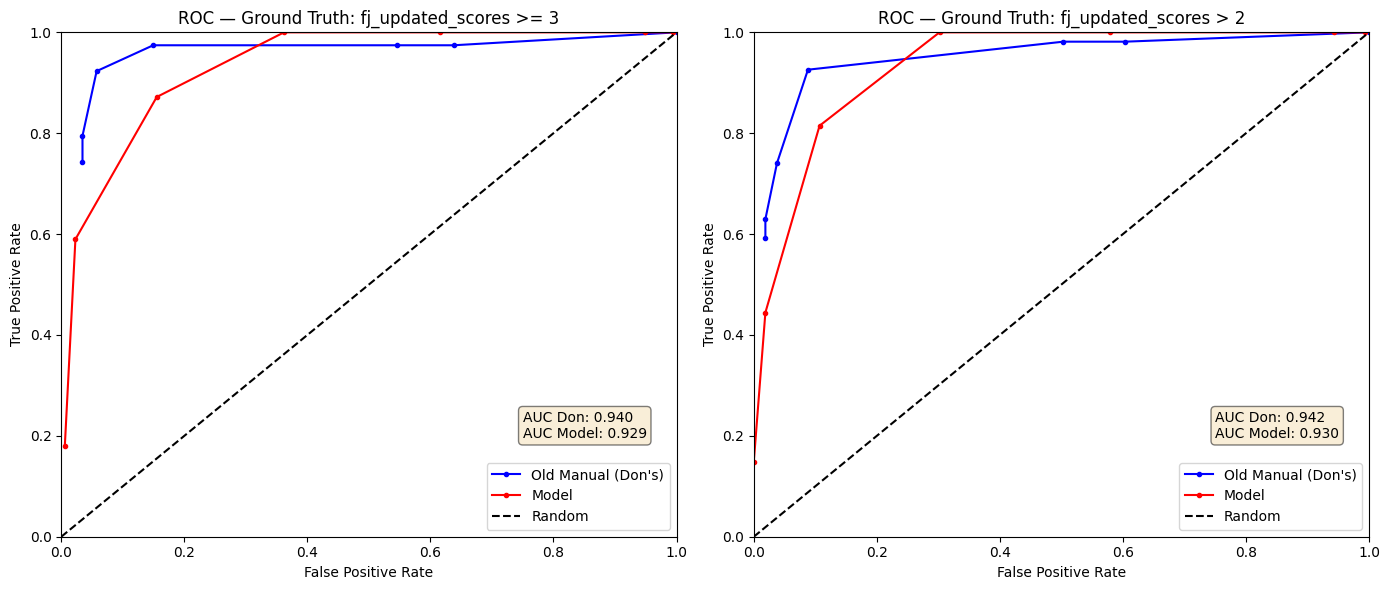

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (gt_name, res) in enumerate(results.items()):
    ax = axes[idx]
    ax.set_title(f'ROC — Ground Truth: {res["desc"]}')
    ax.plot(res['fpr_don'], res['tpr_don'], 'b-o', markersize=3, label="Old Manual (Don's)")
    ax.plot(res['fpr_model'], res['tpr_model'], 'r-o', markersize=3, label='Model')
    ax.plot([0, 1], [0, 1], 'k--', label='Random')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    
    # Compute AUC
    auc_don = abs(np.trapezoid(res['tpr_don'], res['fpr_don']))
    auc_model = abs(np.trapezoid(res['tpr_model'], res['fpr_model']))
    ax.text(0.75, 0.25, f"AUC Don: {auc_don:.3f}\nAUC Model: {auc_model:.3f}", 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

In [59]:
#merged_scores_old_manual_v_new_manual = merged_scores[[f"old_manual_label_{threshold}" for threshold in thresholds] + [f"manual_label_{threshold}" for threshold in thresholds]]
#merged_scores_old_manual_v_new_manual.head()

In [60]:
#merged_scores_model_v_new_manual = merged_scores[[f"model_label_{threshold}" for threshold in thresholds] + [f"manual_label_{threshold}" for threshold in thresholds]]
#merged_scores_model_v_new_manual.head()

In [61]:
#analysis_dfs = [merged_scores_old_manual_v_new_manual, merged_scores_model_v_new_manual]
#analysis_dfs

In [62]:
# markdown_content = "# Comparison of Model Predictions and Old Manual Labels to New Manual Labels\n\n"
# markdown_content += "| y_pred | Threshold | Totals| TP | FP | TN | FN | Accuracy | PPV | NPV |\n"
# markdown_content += "| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n"

# for df in analysis_dfs:
#     print(df.head())
#     print(df.columns)
    
#     metrics = []

#     for threshold in thresholds:
#         prediction_column = f"model_label_{threshold}" if "model_label" in df.columns[0] else f"old_manual_label_{threshold}"
#         print(f"Analyzing {prediction_column} compared to new manual labels...")
        
#         predicted = df[prediction_column]
#         print(f"Predicted labels for threshold {threshold}:\n{predicted.head()}")
#         actual = df[f"manual_label_{threshold}"]
#         print(f"Actual labels for threshold {threshold}:\n{actual.head()}")
#         tp = np.sum((predicted == True) & (actual == True))
#         fp = np.sum((predicted == True) & (actual == False))
#         tn = np.sum((predicted == False) & (actual == False))
#         fn = np.sum((predicted == False) & (actual == True))

#         accuracy = (tp + tn) / (tp + fp + tn + fn) if (tp + fp + tn + fn) > 0 else 0
#         ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
#         npv = tn / (tn + fn) if (tn + fn) > 0 else 0

#         markdown_content += f"| {prediction_column} | {threshold} | {tp + fp + tn + fn} | {tp} | {fp} | {tn} | {fn} | {accuracy:.4f} | {ppv:.4f} | {npv:.4f} |\n"
        
#         metrics.append({
#             'y_pred': prediction_column,
#             'threshold': threshold,
#             'accuracy': accuracy,
#             'ppv': ppv,
#             'npv': npv
#         })

In [77]:
output_md = f"comparison_to_new_manual_labels.md"

with open(output_md, 'w') as f:
    f.write(markdown_content)

In [51]:
# # create a table of accuracy, ppv, and npv comparing dons_scores and predicted_qu_motion_score to fj_updated_scores at each score threshold: 0.5, 1.0, 1.5, 2.0, 2.5, 3.0

# thresholds = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
# results = []
# for threshold in thresholds:
#     # create binary labels for the manual scores using the threshold
#     merged_scores["manual_label"] = merged_scores["fj_updated_scores"] >= threshold
#     print(merged_scores[["fj_updated_scores", "manual_label"]].head())
#     # create binary labels for the model scores using the threshold
#     merged_scores["model_label"] = merged_scores["predicted_qu_motion_score"] >= threshold
#     print(merged_scores[["predicted_qu_motion_score", "model_label"]].head())
#     # calculate accuracy, ppv, and npv for the model scores compared to the manual scores
#     accuracy = accuracy_score(merged_scores["manual_label"], merged_scores["model_label"])
#     ppv = precision_score(merged_scores["manual_label"], merged_scores["model_label"])
#     npv = precision_score(merged_scores["manual_label"], merged_scores["model_label"], pos_label=0)
#     results.append({"threshold": threshold, "accuracy": accuracy, "ppv": ppv, "npv": npv})
# results_df = pd.DataFrame(results)
# results_df

